# IEOR 242A — Homework 5 Clustering & PCA

In this homework, you will investigate how **unsupervised learning methods** can be used as **pre-processing / feature engineering** steps in a supervised learning pipeline.

We will use the **MAGIC Gamma Telescope** dataset from the UCI repository:

- Each observation corresponds to an event detected by an atmospheric Cherenkov telescope.
- There are **10 continuous features** describing the shape/size of the shower image (e.g., length, width, asymmetry, distance).
- The goal is to classify each event as: **gamma (signal)** or **hadron (background)**.

In this notebook, you will:

1. Fit a baseline **logistic regression** model on the original standardized features.
2. Apply **PCA**:
   - Explore the variance explained by each principal component (scree + cumulative plots),
   - Visualize the data in a low-dimensional PC space (PC1–PC2) colored by class,
   - Fit logistic regression on the first \(k\) PCs for several values of \(k\) and compare with the baseline.
3. Use **clustering in PCA space** and treat cluster assignments as features:
   - Run K-means on a PCA representation of the data,
   - Add cluster indicators (one-hot encoded) as **additional features** in a single logistic regression model,
   - Observe whether this simple “clustering-as-feature” approach improves performance.
4. Implement a **Cluster-then-Predict** strategy:
   - Use K-means (in PCA space) to partition the training data into \(K\) clusters,
   - Fit a **separate logistic regression model inside each cluster**,
   - For each point, predict using the model associated with its cluster,
   - Compare this mixture of local models to the global baseline and to the clustering-as-feature approach.
5. Reflect on **when and why** PCA and clustering can help or hurt performance:
   - Why PCA (which is unsupervised) does not always improve accuracy,
   - Why simply adding cluster labels as extra features may have limited impact,
   - Why Cluster-then-Predict can sometimes better capture nonlinear structure by using **local** linear models.

At the end, you will export this notebook (with your completed code and written answers) as a PDF and submit it.

In [5]:
# If ucimlrepo is not installed on your environment, uncomment and run:
!pip install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, roc_auc_score

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 0


## Data Loading and Pre-processing (Given)

We will:

1. Fetch the **MAGIC Gamma Telescope** dataset from the UCI repository using `ucimlrepo`.
2. Extract the 10 continuous features and the binary target label.
   - The original labels are `"g"` for gamma (signal) and `"h"` for hadron (background).
   - We will map `"g" → 1` and `"h" → 0`.
3. Create a **train/test split** (70% train, 30% test) with stratification, so that the class balance
   is similar in both sets.
4. **Standardize** each feature using the training data (zero mean, unit variance),
   and apply the same transformation to the test data.

This cell is provided; you do **not** need to modify it. Just run it.


In [6]:
# === Fetch MAGIC Gamma Telescope dataset from UCI ===

magic_gamma_telescope = fetch_ucirepo(id=159)

# Features and target as DataFrames
X_df = magic_gamma_telescope.data.features       # shape (n_samples, 10)
y_df = magic_gamma_telescope.data.targets        # one column, values 'g' or 'h'

print("X_df shape:", X_df.shape)
print("Target columns:", y_df.columns)

# Convert y to 1D array and map labels: 'g' -> 1 (gamma), 'h' -> 0 (hadron)
y_raw = y_df.iloc[:, 0].values
y = np.where(y_raw == "g", 1, 0)

print("Class counts [0=hadron, 1=gamma]:", np.bincount(y))

feature_names = list(X_df.columns)
X = X_df.values

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

# Standardize features using training data
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

print("X_train_std shape:", X_train_std.shape)
print("X_test_std shape:", X_test_std.shape)


X_df shape: (19020, 10)
Target columns: Index(['class'], dtype='object')
Class counts [0=hadron, 1=gamma]: [ 6688 12332]
X_train_std shape: (13314, 10)
X_test_std shape: (5706, 10)


## Part (A): Baseline Logistic Regression (No Regularization)

In this part, you will fit a **baseline logistic regression model** using the original
10 standardized features.

**Tasks:**

1. Fit a logistic regression model on `X_train_std`, `y_train`.
2. Use the fitted model to predict on both the training and test sets.
3. Compute and report:
   - Training & Test accuracy,
   - Training & Test AUC.
4. Briefly comment on the performance and whether there seems to be room for improvement.

Fill in the `TODO` parts in the code cell below.


In [7]:
# === Part (A): Baseline logistic regression ===

# TODO: create a LogisticRegression model
log_reg_base = LogisticRegression(random_state = RANDOM_STATE)

# TODO: fit the model on the training data (X_train_std, y_train)
log_reg_base.fit(X_train_std, y_train)

# === Predictions ===
# TODO: compute predicted class labels on train and test sets
y_train_pred = log_reg_base.predict(X_train_std)
y_test_pred = log_reg_base.predict(X_test_std)

# TODO: compute predicted probabilities for the positive class (gamma=1)
y_train_prob = log_reg_base.predict_proba(X_train_std)
y_test_prob = log_reg_base.predict_proba(X_test_std)

# === Metrics ===
# TODO: compute train and test accuracy
train_acc_base = accuracy_score(y_train, y_train_pred)
test_acc_base = accuracy_score(y_test, y_test_pred)

# TODO: compute train and test AUC
train_auc_base = roc_auc_score(y_train, y_train_prob[:,1])
test_auc_base = roc_auc_score(y_test, y_test_prob[:,1])

print("Baseline logistic regression (no regularization):")
print("  Train accuracy:", train_acc_base)
print("  Test  accuracy:", test_acc_base)
print("  Train AUC:", train_auc_base)
print("  Test  AUC:", test_auc_base)


Baseline logistic regression (no regularization):
  Train accuracy: 0.7910470181763557
  Test  accuracy: 0.7893445495969156
  Train AUC: 0.8388799917575207
  Test  AUC: 0.8425664897200291


### Part (A) short answer

In 3–4 sentences, comment on the baseline model:

- Is there a noticeable gap between **training** and **test** performance?
- Does the model appear to underfit, overfit, or perform reasonably well?
- Do you think there is room for improvement (e.g., using more flexible models or better features)?

*(Type your answer here.)*\
Accuracy and AUC scores are almost the same between the train and test set, which suggests, there is no significant gap between their performances. The model seems to perform reasonably well. There is no overfitting seems to be present since test performance is nearly the same as training performance and there is no strong sign  of underfitting as accuracy and AUC are not extremely low. However, there is room for improvement because logistic regression is rather simple, linear model and thus may not fully capture the pattern when underlying relationship is more complex.


## Part (B): PCA for Exploration and Dimensionality Reduction

In this part, you will use **Principal Component Analysis (PCA)** on the standardized
training features:

1. Fit PCA on `X_train_std` with all components (10).
2. Create a **cumulative variance** plot: cumulative variance explained as a function of the number of components.
3. Visualize the training data in the **PC1–PC2 plane**, colored by class (gamma vs hadron).
4. For several values of \(k\) (e.g. \(k = 2, 3, 5, 8, 10\)):
   - Transform the training and test data to the first \(k\) PCs,
   - Fit a logistic regression model on the transformed data,
   - Compute training and test accuracy and AUC.
5. Compare the PCA-based models to the baseline model from Part (A).

**Key ideas:**

- PCA is **unsupervised**: it looks only at the covariance of `X`, not at the labels `y`.
- It orders directions by **variance**, not by how predictive they are for the class label.
- Using a small number of PCs may reduce variance (fewer effective features) but can lose
  important class information.

Complete the TODOs in the following cells.


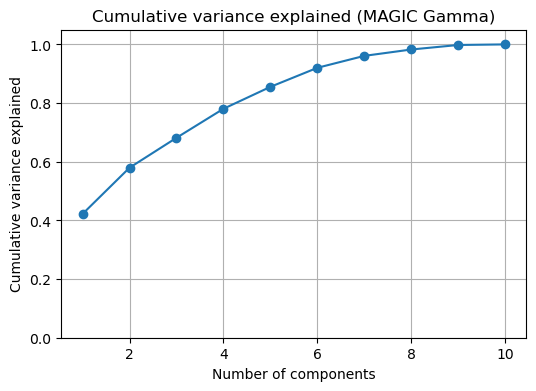

In [8]:
# === Part (B.1): Fit PCA on training data ===

# TODO: create a PCA object with n_components=None and random_state=RANDOM_STATE
pca_full = PCA(n_components = None, random_state = RANDOM_STATE)

# TODO: fit PCA on X_train_std
pca_full.fit(X_train_std)

# Explained variance ratios
var_ratio = pca_full.explained_variance_ratio_       # variance (ratio) explained by each component
cum_var_ratio = np.cumsum(var_ratio)    # cumulative variance (ratio) explained
n_components = 10     # number of components

# Cumulative variance explained plot
plt.figure()
plt.plot(range(1, n_components + 1), cum_var_ratio, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance explained")
plt.title("Cumulative variance explained (MAGIC Gamma)")
plt.ylim(0, 1.05)
plt.show()


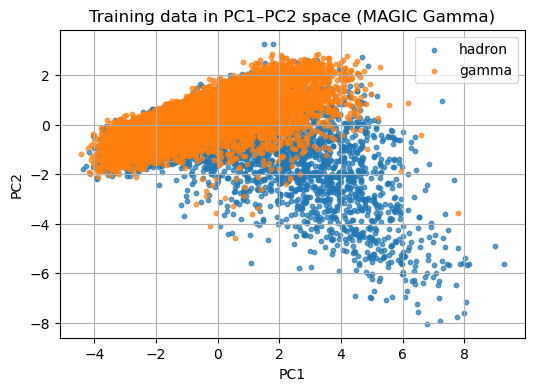

In [9]:
# === Part (B.2): PC1–PC2 scatter colored by class ===

# TODO: transform X_train_std using pca_full
X_train_pca_full = pca_full.fit_transform(X_train_std)

# First two principal components
pc1 = X_train_pca_full[:, 0]
pc2 = X_train_pca_full[:, 1]

plt.figure()
for label, name, color in [(0, "hadron", "tab:orange"), (1, "gamma", "tab:blue")]:
    mask = (y_train == label)
    plt.scatter(pc1[mask], pc2[mask], s=10, label=name, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Training data in PC1–PC2 space (MAGIC Gamma)")
plt.legend()
plt.show()


### Part (B.2) short answer: PC1–PC2 visualization

In 3–5 sentences, comment on the PC1–PC2 plot:

- Do the gamma and hadron classes appear well separated in this 2D projection?
- Are there clear clusters, overlaps, or outliers?
- Based on this visualization alone, does the classification problem look easy or hard?

*(Type your answer here.)*\
The two classes are not quite well separated; their scatter plots overlap with each other.


In [10]:
# === Part (B.3): Logistic regression on first k PCs ===

ks = [2, 3, 5, 8, 10]

results_pca = []

for k in ks:
    # TODO: create PCA with n_components=k and fit on X_train_std
    pca_k = PCA(n_components=k, random_state=RANDOM_STATE)
    pca_k.fit(X_train_std)
    
    # TODO: transform training and test data
    X_train_pca_k = pca_k.fit_transform(X_train_std)
    X_test_pca_k = pca_k.transform(X_test_std)
    
    # TODO: create logistic regression model
    log_reg_k = LogisticRegression(random_state=RANDOM_STATE)
    
    # TODO: fit on X_train_pca_k, y_train
    log_reg_k.fit(X_train_pca_k, y_train)
    
    # Predictions and probabilities
    y_train_pred_k = log_reg_k.predict(X_train_pca_k)
    y_test_pred_k = log_reg_k.predict(X_test_pca_k)
    y_train_prob_k = log_reg_k.predict_proba(X_train_pca_k)
    y_test_prob_k = log_reg_k.predict_proba(X_test_pca_k)
    
    # Metrics
    train_acc_k = accuracy_score(y_train, y_train_pred_k)
    test_acc_k = accuracy_score(y_test, y_test_pred_k)
    train_auc_k = roc_auc_score(y_train, y_train_prob_k[:,1])
    test_auc_k = roc_auc_score(y_test, y_test_prob_k[:,1])
    
    results_pca.append({
        "k": k,
        "train_accuracy": train_acc_k,
        "test_accuracy": test_acc_k,
        "train_auc": train_auc_k,
        "test_auc": test_auc_k
    })

results_pca_df = pd.DataFrame(results_pca)
results_pca_df


,k,train_accuracy,test_accuracy,train_auc,test_auc
0,2,0.744930,0.739047,0.757658,0.760671
1,3,0.756497,0.753417,0.782938,0.783151
2,5,0.781658,0.784087,0.824556,0.829651
3,8,0.787592,0.784963,0.835685,0.839347
4,10,0.791122,0.789345,0.838879,0.842556


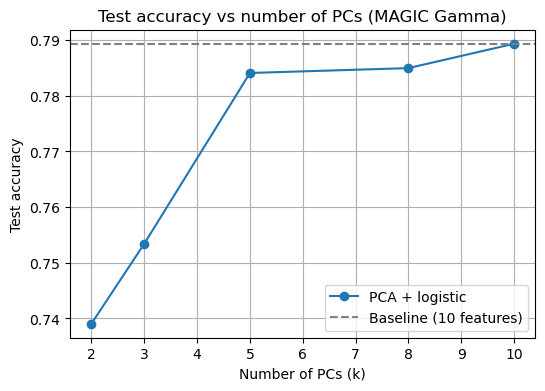

,k,train_accuracy,test_accuracy,train_auc,test_auc
0,2,0.744930,0.739047,0.757658,0.760671
1,3,0.756497,0.753417,0.782938,0.783151
2,5,0.781658,0.784087,0.824556,0.829651
3,8,0.787592,0.784963,0.835685,0.839347
4,10,0.791122,0.789345,0.838879,0.842556


In [11]:
# === Part (B.4): Plot test accuracy vs k and compare to baseline ===

plt.figure()
plt.plot(results_pca_df["k"], results_pca_df["test_accuracy"], marker="o", label="PCA + logistic")
plt.axhline(test_acc_base, linestyle="--", color="gray", label="Baseline (10 features)")
plt.xlabel("Number of PCs (k)")
plt.ylabel("Test accuracy")
plt.title("Test accuracy vs number of PCs (MAGIC Gamma)")
plt.legend()
plt.grid(True)
plt.show()

results_pca_df


### Part (B) short answer: Comparing PCA-based models to baseline

Using your table and the plot:

- How does **test accuracy** change as \(k\) increases?
- Is there a “sweet spot” for \(k\)?
- Do any PCA-based models **match or outperform** the baseline?

*(Type your answer here.)*\
Test accuracy moves up and down a little as k increases; it does not increase or decrease linearly. If we can define the sweet spot for K as the K that achieves the highest accuracy it is 2 in this case. PCA-based models, regardless of the number of PCs, are not as good as the baseline model in this particular example. Their test accuracy is around 0.67 whereas test accuracy from the baseline model is over 0.78. Also, test accuracy is notably lower than train accrucy with PCA models in general, which suggests there might be potential overfitting.

## Part (C1): Clustering-as-Feature

We now introduce **clustering** into the pipeline.

One simple idea is to:

1. Project the data into a low-dimensional **PCA space** (to denoise and reduce dimension).
2. Run **K-means** to find \(K\) clusters (groups of similar events) in this PCA space.
3. For each point, create **cluster indicator features** (one-hot encoding of the cluster ID).
4. Append these cluster indicator features to the original standardized features and fit a **single**
   global logistic regression model.

Intuition:

- If different regions of feature space correspond to different typical behavior
  (e.g., some clusters are more likely to be gamma, others more likely hadron),
  then cluster indicators might help the global linear model by adding extra “segments”.
- However, this is still **one global model**; only the intercepts (and maybe effective slopes) can shift
  per cluster via these indicator variables.

Later, we will compare this to **Cluster-then-Predict**, where each cluster has its own separate model.


In [12]:
# === Part (C1.1): PCA space for clustering ===

k_cluster_pca = 5   # dimension for clustering PCA
K = 4               # number of clusters for K-means

# TODO: create PCA with n_components=k_cluster_pca and random_state=RANDOM_STATE
pca_cluster = PCA(n_components = k_cluster_pca, random_state = RANDOM_STATE)
# TODO: fit PCA on X_train_std
pca_cluster.fit(X_train_std)

# TODO: transform train and test into this PCA space
X_train_cluster = pca_cluster.fit_transform(X_train_std)
X_test_cluster = pca_cluster.transform(X_test_std)

# === Part (C1.2): K-means clustering ===

# TODO: create KMeans with n_clusters=K, random_state=RANDOM_STATE, n_init=10
kmeans = KMeans(n_clusters = K, random_state = RANDOM_STATE, n_init = 10)

# TODO: fit KMeans on X_train_cluster
kmeans.fit(X_train_cluster)

# Cluster assignments
cluster_train = kmeans.predict(X_train_cluster)
cluster_test = kmeans.predict(X_test_cluster)

print("Cluster counts (train):", np.bincount(cluster_train))
print("Cluster counts (test): ", np.bincount(cluster_test))


C:\Users\natal\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\natal\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\natal\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\natal\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Cluster counts (train): [4141  864 3064 5245]
Cluster counts (test):  [1762  336 1320 2288]


In [13]:
# === Part (C1.3): Build cluster dummy (one-hot) features and augment X ===

# TODO: create one-hot encoded cluster features for train and test
cluster_train_df = pd.get_dummies(cluster_train, prefix="cluster")
cluster_test_df = pd.get_dummies(cluster_test, prefix="cluster")

# Ensure train and test dummy matrices have the same columns
# Hint: use reindex with columns=cluster_train_df.columns, fill_value=0
cluster_test_df = cluster_test_df.reindex(columns=cluster_train_df.columns, fill_value=0)

# Convert standardized arrays to DataFrames for easier concatenation
X_train_std_df = pd.DataFrame(X_train_std, columns=feature_names)
X_test_std_df = pd.DataFrame(X_test_std, columns=feature_names)

# TODO: horizontally concatenate original features with cluster dummy features
X_train_aug = pd.concat([X_train_std_df, cluster_train_df], axis=1) 
X_test_aug = pd.concat([X_test_std_df, cluster_test_df], axis=1)

print("Original feature shape:", X_train_std_df.shape)
print("Augmented feature shape:", X_train_aug.shape)


Original feature shape: (13314, 10)
Augmented feature shape: (13314, 14)


In [15]:
# === Part (C1.4): Logistic regression: original vs original + cluster features ===

# Model 1: original 10 standardized features (re-fit for a clean comparison)
# TODO: fit on X_train_std, y_train
log_reg_k.fit(X_train_std, y_train)

y_train_pred_orig = log_reg_k.predict(X_train_std)
y_test_pred_orig = log_reg_k.predict(X_test_std)

train_acc_orig = accuracy_score(y_train, y_train_pred_orig)
test_acc_orig = accuracy_score(y_test, y_test_pred_orig)

# Model 2: original + cluster dummies
log_reg_aug = LogisticRegression(random_state = RANDOM_STATE)
# TODO: fit on X_train_aug, y_train
log_reg_aug.fit(X_train_aug, y_train)

y_train_pred_aug = log_reg_aug.predict(X_train_aug)
y_test_pred_aug = log_reg_aug.predict(X_test_aug)

train_acc_aug = accuracy_score(y_train, y_train_pred_aug)
test_acc_aug = accuracy_score(y_test, y_test_pred_aug)

print("Global logistic (original 10 features):")
print("  Train accuracy:", train_acc_orig)
print("  Test  accuracy:", test_acc_orig)

print("\nGlobal logistic (original + cluster dummies):")
print("  Train accuracy:", train_acc_aug)
print("  Test  accuracy:", test_acc_aug)


Global logistic (original 10 features):
  Train accuracy: 0.7910470181763557
  Test  accuracy: 0.7893445495969156

Global logistic (original + cluster dummies):
  Train accuracy: 0.7945020279405137
  Test  accuracy: 0.7935506484402384


### Part (C1) short answer: Clustering-as-Feature

Compare the two global models. Briefly comment on whether cluster indicators seem to add useful signal.

*(Write 3–5 sentences.)*


## Part (C2): Cluster-then-Predict

Now we implement the **Cluster-then-Predict** strategy:

1. Use the **same clustering** as in Part (C1):
   - PCA space with dimension \(k_cluster = 5\),
   - K-means with \(K = 4\) clusters.
2. For each cluster \(c\), fit an **logistic regression model** using only the training points whose cluster label is \(c\).
3. For each point (train and test):
   - Use the K-means model to assign it to a cluster,
   - Use the logistic regression model trained on that cluster to make the prediction.
4. Evaluate the overall performance (across all points) in terms of accuracy and AUC.

Intuition:

- Instead of one global linear boundary, we now have **K local linear models**, one per cluster.
- This can approximate a more complex nonlinear boundary by stitching together several local lines.
- However, it also increases model complexity (more parameters) and can be unstable if clusters are small.

Complete the TODOs below.


In [ ]:
# === Part (C2.1): Fit one logistic regression per cluster ===

cluster_models = {}

for c in range(K):
    idx_c = (cluster_train == c)
    X_c = X_train_std[idx_c]
    y_c = y_train[idx_c]
    
    print(f"Cluster {c}: {X_c.shape[0]} training points")
    
    # TODO: create a logistic regression model for this cluster
    model_c = None
    
    # TODO: fit model_c on X_c, y_c
    # model_c.fit(...)
    
    cluster_models[c] = model_c

print("Number of trained cluster models:", len(cluster_models))


In [ ]:
# === Part (C2.2): Cluster-then-Predict: predictions and metrics ===

# Initialize arrays
y_train_pred_ctp = np.zeros_like(y_train)
y_train_prob_ctp = np.zeros_like(y_train, dtype=float)

y_test_pred_ctp = np.zeros_like(y_test)
y_test_prob_ctp = np.zeros_like(y_test, dtype=float)

# For each cluster, use its local model where available
for c, model_c in cluster_models.items():
    # Training points in cluster c
    idx_train_c = (cluster_train == c)
    if np.any(idx_train_c):
        # TODO: predict labels and probabilities for training points in cluster c
        # y_train_pred_ctp[idx_train_c] = ...
        # y_train_prob_ctp[idx_train_c] = ...
    
    # Test points in cluster c
    idx_test_c = (cluster_test == c)
    if np.any(idx_test_c):
        # TODO: predict labels and probabilities for test points in cluster c
        # y_test_pred_ctp[idx_test_c] = ...
        # y_test_prob_ctp[idx_test_c] = ...

# TODO: compute train and test accuracy and AUC for Cluster-then-Predict
train_acc_ctp = None
test_acc_ctp = None
train_auc_ctp = None
test_auc_ctp = None

print("Cluster-then-Predict (logistic regression in each cluster):")
print("  Train accuracy:", train_acc_ctp)
print("  Test  accuracy:", test_acc_ctp)
print("  Train AUC:", train_auc_ctp)
print("  Test  AUC:", test_auc_ctp)


### Part (C2) short answer: Cluster-then-Predict vs global models

Compare **Cluster-then-Predict** to:

- the baseline global logistic regression from Part (A), and
- the clustering-as-feature global model from Part (C1).

Discuss:

- How do the train and test accuracies/AUCs compare across these three approaches?
- Comment on why Cluster-then-Predict might be more advantageous

*(Write your answer here.)*


## Part (D): Overall Reflection

Using your results from all parts, propose **practical guidelines** about when you would:
   - consider using PCA as pre-processing, and
   - consider using a Clustering-as-Feature strategy in a supervised learning problem, and
   - consider using a Cluster-then-Predict strategy in a supervised learning problem.

